# CSIS 3290 – 004 – Project 1
- Student Name: Isaac David Rangel Blanco
- ID: 300410730

The references used to create the linear regression models to predict the course number ratings:

- All the knowledge in Python coding and/or techniques covered in the class

- The video recording on Week 05 Extra folder on the blackboard

In [1]:
# Necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import f_regression 
from sklearn.feature_selection import SelectKBest
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [2]:
# Loading the dataset prepared from previous lab2

df = pd.read_csv('dataset/Lab02_prepared.csv')

# Having a peek on the data too check that the content is correct

df.head()

,CourseCategory,InstRating,Lectures,Duration,AvgRating,LastUpdated,Fee,Discount,cbrt_NumberRatings,cbrt_Enrollment,cbrt_Student,cbrt_Review
0,business,4.5,286.0,9.800000,4.6,6.0,19.99,88.0,27.951020,48.974581,74.041978,44.791629
1,programming,4.2,66.0,4.966667,4.2,6.0,16.99,88.0,11.416535,20.853094,31.853168,17.819177
2,it_software,4.5,251.0,93.150000,4.4,8.0,17.99,89.0,19.004616,31.409753,72.232850,36.717597
3,it_software,4.7,26.0,2.050000,4.7,6.0,16.99,80.0,16.913051,25.146869,35.740678,24.546490
4,personal_development,4.4,82.0,11.066667,4.4,9.0,16.99,83.0,8.946181,17.940130,41.425278,25.027703


In [3]:
# Getting some importan info of the dataset

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1883 entries, 0 to 1882
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CourseCategory      1883 non-null   object 
 1   InstRating          1883 non-null   float64
 2   Lectures            1883 non-null   float64
 3   Duration            1883 non-null   float64
 4   AvgRating           1883 non-null   float64
 5   LastUpdated         1883 non-null   float64
 6   Fee                 1883 non-null   float64
 7   Discount            1883 non-null   float64
 8   cbrt_NumberRatings  1883 non-null   float64
 9   cbrt_Enrollment     1883 non-null   float64
 10  cbrt_Student        1883 non-null   float64
 11  cbrt_Review         1883 non-null   float64
dtypes: float64(11), object(1)
memory usage: 176.7+ KB


CourseCategory        0
InstRating            0
Lectures              0
Duration              0
AvgRating             0
LastUpdated           0
Fee                   0
Discount              0
cbrt_NumberRatings    0
cbrt_Enrollment       0
cbrt_Student          0
cbrt_Review           0
dtype: int64

- We can notice that there is only one column with datatype object this was a previous requierement, also some changes or convertions To the columns NumberRatings, Enrollment, Student and Review
- Also there is not null values in any column

In [4]:
# Removing/Dropping the Index 

df.reset_index(drop=True, inplace=True)
df.columns

# Visually Jupyter Nootebook still showing a index column, but this is not included as a feature in the dataset

Index(['CourseCategory', 'InstRating', 'Lectures', 'Duration', 'AvgRating',
       'LastUpdated', 'Fee', 'Discount', 'cbrt_NumberRatings',
       'cbrt_Enrollment', 'cbrt_Student', 'cbrt_Review'],
      dtype='object')

# Task 3 - Exploratory Data Analysis

In [5]:
# Summary Statistics of the dataset

df.describe()

,InstRating,Lectures,Duration,AvgRating,LastUpdated,Fee,Discount,cbrt_NumberRatings,cbrt_Enrollment,cbrt_Student,cbrt_Review
count,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000
mean,4.430589,105.238449,12.162454,4.423686,6.757302,21.758858,78.566649,12.610265,22.852516,46.203082,26.566290
std,0.187973,99.708331,13.453022,0.235237,1.292932,19.386842,16.455207,5.883152,10.069789,26.382564,16.771227
min,3.800000,5.000000,1.000000,2.700000,6.000000,9.301800,30.000000,2.571282,3.301927,3.802952,3.141381
25%,4.300000,44.000000,4.416667,4.300000,6.000000,16.990000,74.000000,8.549880,15.649948,25.545095,13.898024
50%,4.500000,74.000000,7.883333,4.500000,6.000000,17.990000,86.000000,11.281967,21.072313,39.887601,22.521297
75%,4.600000,125.000000,14.450000,4.600000,7.000000,21.990000,89.000000,15.123426,27.463643,61.453310,34.811229
max,4.800000,699.000000,164.000000,4.900000,15.000000,199.990000,92.000000,39.466029,59.825512,129.445070,86.756354


In [6]:
# Correlation features 

df.corr(numeric_only=True).cbrt_NumberRatings.abs().sort_values(ascending=False)[1:]

cbrt_Enrollment    0.922071
cbrt_Review        0.556788
cbrt_Student       0.495890
InstRating         0.350330
AvgRating          0.317351
Lectures           0.037687
Fee                0.030926
Duration           0.022431
Discount           0.009295
LastUpdated        0.007541
Name: cbrt_NumberRatings, dtype: float64

In [7]:
# create a copy of the original dataset, but without the CourseCategory column, because this is not numeric 
# But its possible to convert it to numeric using Dummy features

dfnum = df.copy()
dfnum.drop('CourseCategory', axis=1, inplace=True)
dfnum.reset_index(drop=True, inplace=True)
dfnum.head()

,InstRating,Lectures,Duration,AvgRating,LastUpdated,Fee,Discount,cbrt_NumberRatings,cbrt_Enrollment,cbrt_Student,cbrt_Review
0,4.5,286.0,9.800000,4.6,6.0,19.99,88.0,27.951020,48.974581,74.041978,44.791629
1,4.2,66.0,4.966667,4.2,6.0,16.99,88.0,11.416535,20.853094,31.853168,17.819177
2,4.5,251.0,93.150000,4.4,8.0,17.99,89.0,19.004616,31.409753,72.232850,36.717597
3,4.7,26.0,2.050000,4.7,6.0,16.99,80.0,16.913051,25.146869,35.740678,24.546490
4,4.4,82.0,11.066667,4.4,9.0,16.99,83.0,8.946181,17.940130,41.425278,25.027703


In [8]:
dfnum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1883 entries, 0 to 1882
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   InstRating          1883 non-null   float64
 1   Lectures            1883 non-null   float64
 2   Duration            1883 non-null   float64
 3   AvgRating           1883 non-null   float64
 4   LastUpdated         1883 non-null   float64
 5   Fee                 1883 non-null   float64
 6   Discount            1883 non-null   float64
 7   cbrt_NumberRatings  1883 non-null   float64
 8   cbrt_Enrollment     1883 non-null   float64
 9   cbrt_Student        1883 non-null   float64
 10  cbrt_Review         1883 non-null   float64
dtypes: float64(11)
memory usage: 161.9 KB


In [9]:
# checking the correlation again and getting a list with the specific features that have a strong correlation

corr_val = dfnum.corr(numeric_only=True).cbrt_NumberRatings.abs().sort_values(ascending=False).round(2)[1:]
list = corr_val[corr_val >= 0.5].index.to_list()
print(list)

['cbrt_Enrollment', 'cbrt_Review', 'cbrt_Student']


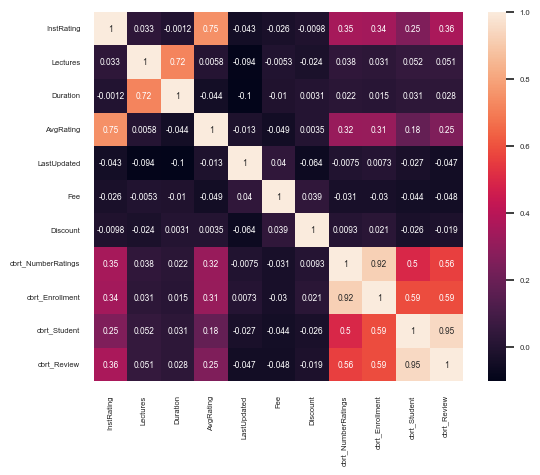

In [10]:
# Now we can map the heatmap of the correlation

cm = np.corrcoef(dfnum.values.T)

sns.set(font_scale=0.5)
sns.heatmap(cm,
            square=True,
            annot=True,
            yticklabels=dfnum.columns,
            xticklabels=dfnum.columns)
plt.show()

- By looking in the heat map, and having as target the **cbrt_NumberRatings** column, is possible to see the correlation
and confirm that cbrt_Enrrolment, cbrt_Student and cbrt_Review have a appropieate correlation value

# Univariate Analysis 
- Univariate analysis its done by creating Distribution plot for cbrt_NumberRatings, to check for outliners

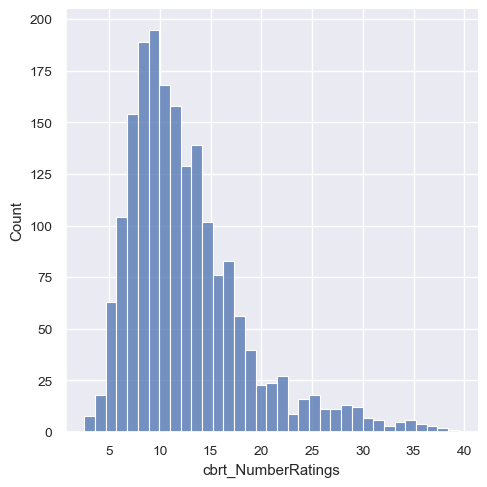

In [11]:
# Displot() for Univariate analysis 

sns.set(font_scale=0.9)
sns.displot(dfnum['cbrt_NumberRatings'])

- It is possible to see that there are some outliers, possibly after values around 25 or 30 on the x-axis.
- Considering all the values, the distribution appears to be right-skewed. However, the values between 0 and 25 resemble a normal distribution, although the distribution still presents a longer tail on the right side.

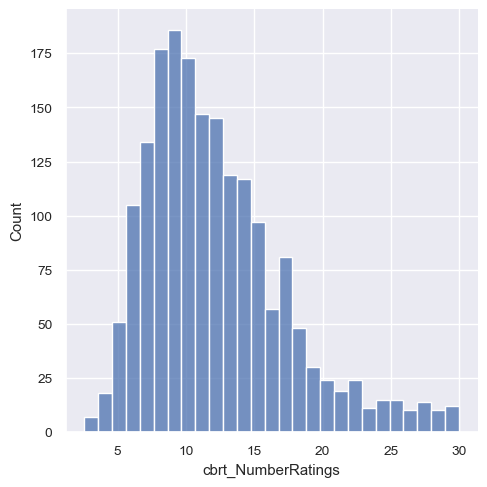

In [12]:
# Dropping the records where cbrt_NumberRatings > 30 , we can get a Normal distribution

dfnum.drop(dfnum[dfnum['cbrt_NumberRatings'] > 30].index, inplace=True)

# Plotting again to check the changes 

sns.displot(dfnum['cbrt_NumberRatings'])

# Multivariate Analysis 
- Multivariate analysis its done by creating some scatter plot comparing cbrt_NumberRatings against any other features that has high correlation

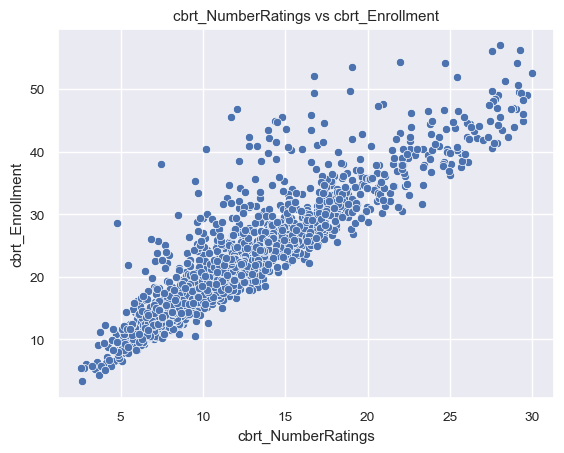

In [13]:
# scatter plot of cbrt_NumberRatings against cbrt_Enrollment

sns.scatterplot(data=dfnum, x='cbrt_NumberRatings', y='cbrt_Enrollment')
plt.title('cbrt_NumberRatings vs cbrt_Enrollment')
plt.show()

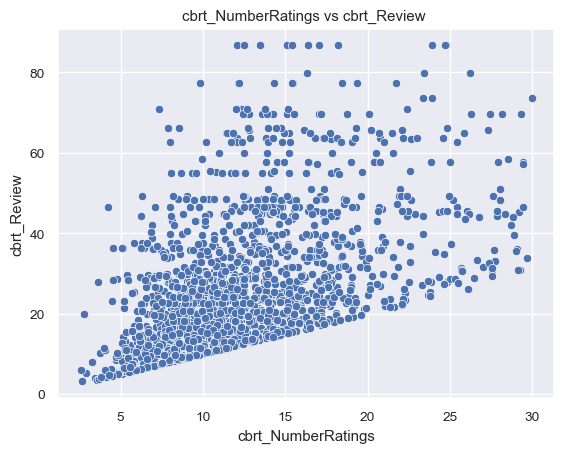

In [14]:
# scatter plot of cbrt_NumberRatings against cbrt_Review 

sns.scatterplot(data=dfnum, x='cbrt_NumberRatings', y='cbrt_Review')
plt.title('cbrt_NumberRatings vs cbrt_Review ')
plt.show()

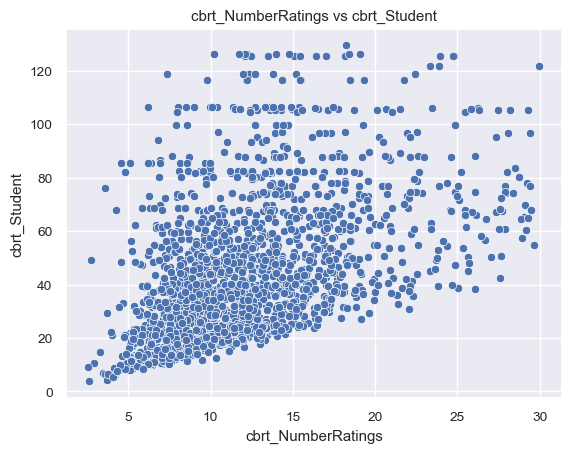

In [15]:
# scatter plot of cbrt_NumberRatings against cbrt_Student

sns.scatterplot(data=dfnum, x='cbrt_NumberRatings', y='cbrt_Student')
plt.title('cbrt_NumberRatings vs cbrt_Student')
plt.show()

- By looking at the scatter plots, we can notice that there is an almost linear relationship between the selected features and the target. It also appears to be a strong positive relationship.

- We can also observe a dispersion of the data as the values increase. This is more noticeable in the scatter plots with cbrt_student and cbrt_Review.

- We can observe that the correlation values and the heatmap are consistent with these results, showing that the cbrt_Enrollment feature has the highest correlation with the target variable.

# Task 4 - Feature Selection
- Create several dataframes to store the results of the following feature selection methods to be used later in the modeling.

In [16]:
# Creating a new copy of the dfnum dataset, to keep this as a original

df2 = dfnum.copy()
df2.reset_index(drop=True, inplace=True)
df2.head()

,InstRating,Lectures,Duration,AvgRating,LastUpdated,Fee,Discount,cbrt_NumberRatings,cbrt_Enrollment,cbrt_Student,cbrt_Review
0,4.5,286.0,9.800000,4.6,6.0,19.99,88.0,27.951020,48.974581,74.041978,44.791629
1,4.2,66.0,4.966667,4.2,6.0,16.99,88.0,11.416535,20.853094,31.853168,17.819177
2,4.5,251.0,93.150000,4.4,8.0,17.99,89.0,19.004616,31.409753,72.232850,36.717597
3,4.7,26.0,2.050000,4.7,6.0,16.99,80.0,16.913051,25.146869,35.740678,24.546490
4,4.4,82.0,11.066667,4.4,9.0,16.99,83.0,8.946181,17.940130,41.425278,25.027703


In [17]:
# using .info() 

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   InstRating          1846 non-null   float64
 1   Lectures            1846 non-null   float64
 2   Duration            1846 non-null   float64
 3   AvgRating           1846 non-null   float64
 4   LastUpdated         1846 non-null   float64
 5   Fee                 1846 non-null   float64
 6   Discount            1846 non-null   float64
 7   cbrt_NumberRatings  1846 non-null   float64
 8   cbrt_Enrollment     1846 non-null   float64
 9   cbrt_Student        1846 non-null   float64
 10  cbrt_Review         1846 non-null   float64
dtypes: float64(11)
memory usage: 158.8 KB


# Manual selection of correlation 

In [18]:
# in my case, I am going to select the first seven features in the list below.
 
df2.corr().cbrt_NumberRatings.abs().sort_values(ascending=False)[1:]

cbrt_Enrollment    0.907349
cbrt_Review        0.530124
cbrt_Student       0.479917
InstRating         0.340117
AvgRating          0.303100
Fee                0.039840
Lectures           0.036535
Duration           0.019517
LastUpdated        0.007120
Discount           0.003023
Name: cbrt_NumberRatings, dtype: float64

In [19]:
# saving the selected features in a new dataframe 

df_corr = df2[['cbrt_Enrollment', 'cbrt_Review', 'cbrt_Student', 'InstRating', 'AvgRating', 'Fee', 'Lectures']]
df_corr

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures
0,48.974581,44.791629,74.041978,4.5,4.6,19.9900,286.0
1,20.853094,17.819177,31.853168,4.2,4.2,16.9900,66.0
2,31.409753,36.717597,72.232850,4.5,4.4,17.9900,251.0
3,25.146869,24.546490,35.740678,4.7,4.7,16.9900,26.0
4,17.940130,25.027703,41.425278,4.4,4.4,16.9900,82.0
...,...,...,...,...,...,...,...
1841,24.327682,43.108075,64.730800,4.4,4.6,17.9900,23.0
1842,22.029575,20.602501,31.038108,4.6,4.6,21.9900,109.0
1843,22.999370,11.421648,23.682152,4.6,4.6,28.9900,51.0
1844,23.127209,44.324902,60.770435,4.7,4.7,9.3018,56.0


# using the select K-Best method

In [20]:
# Its necessary to selected the target and feature first

target = df2.cbrt_NumberRatings
target.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1846 entries, 0 to 1845
Series name: cbrt_NumberRatings
Non-Null Count  Dtype  
--------------  -----  
1846 non-null   float64
dtypes: float64(1)
memory usage: 14.6 KB


In [21]:
# Saving features

features = df2.drop(['cbrt_NumberRatings'], axis=1) 
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   InstRating       1846 non-null   float64
 1   Lectures         1846 non-null   float64
 2   Duration         1846 non-null   float64
 3   AvgRating        1846 non-null   float64
 4   LastUpdated      1846 non-null   float64
 5   Fee              1846 non-null   float64
 6   Discount         1846 non-null   float64
 7   cbrt_Enrollment  1846 non-null   float64
 8   cbrt_Student     1846 non-null   float64
 9   cbrt_Review      1846 non-null   float64
dtypes: float64(10)
memory usage: 144.3 KB


In [22]:
# Defining 7 features to be selected, to see if i can get the same that i selected before from the manual selection

kbest = SelectKBest(score_func=f_regression, k=7) 

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
kbest.fit_transform(X_train, y_train)
df_selKBest = features.iloc[:,kbest.get_support()]
df_selKBest.head()

,InstRating,AvgRating,Fee,Discount,cbrt_Enrollment,cbrt_Student,cbrt_Review
0,4.5,4.6,19.99,88.0,48.974581,74.041978,44.791629
1,4.2,4.2,16.99,88.0,20.853094,31.853168,17.819177
2,4.5,4.4,17.99,89.0,31.409753,72.232850,36.717597
3,4.7,4.7,16.99,80.0,25.146869,35.740678,24.546490
4,4.4,4.4,16.99,83.0,17.940130,41.425278,25.027703


- Using the two methods, i get almost the same seven features, but manually I selected Lectures, whereas with K-Best, Discount is selected instead.

# Task 5 - Linear Regression Models 
- with Feature Selection, Feature transformation and Scaling


In [23]:
# First its needed to create some empty placeholder list to store the experiment's results

fselection_list = []
ftransform_list = []
r2_list = []
rmse_list = []

# Experiments with Correlation based selected features

In [24]:
# checking the target and features dataframe that was selected and saved from previous step

print(target)  
df_corr.head()

0       27.951020
1       11.416535
2       19.004616
3       16.913051
4        8.946181
          ...    
1841    13.491993
1842    12.304698
1843    11.421648
1844    14.857918
1845     9.375096
Name: cbrt_NumberRatings, Length: 1846, dtype: float64


,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures
0,48.974581,44.791629,74.041978,4.5,4.6,19.99,286.0
1,20.853094,17.819177,31.853168,4.2,4.2,16.99,66.0
2,31.409753,36.717597,72.232850,4.5,4.4,17.99,251.0
3,25.146869,24.546490,35.740678,4.7,4.7,16.99,26.0
4,17.940130,25.027703,41.425278,4.4,4.4,16.99,82.0


# Experiment A
- Linear regression model using the **correlation based** selected features and Robust scaler transformation. 
- Fit and predict the model using the test set and calculate the RMSE and R2 metrics scores

In [25]:
# Robust scaler implementation

rs = RobustScaler()
df_corr_scaled_features = rs.fit_transform(df_corr)

# Creating new data frame with the features scaled

df_corr_scaled = pd.DataFrame(df_corr_scaled_features, columns=df_corr.columns)
df_corr_scaled.head()

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures
0,2.423509,1.134926,0.980624,0.000000,0.333333,0.4,2.617284
1,0.003074,-0.207254,-0.216860,-1.000000,-1.000000,-0.2,-0.098765
2,0.911692,0.733153,0.929274,0.000000,-0.333333,0.0,2.185185
3,0.372642,0.127505,-0.106517,0.666667,0.666667,-0.2,-0.592593
4,-0.247647,0.151451,0.054834,-0.333333,-0.333333,-0.2,0.098765


In [26]:
# Splitting the dataset into train and test subsets

X_train, X_test, Y_train, Y_test = train_test_split(df_corr_scaled, target, test_size=0.25, random_state=42)

# Now build the linear Regression model using the subsets for training

df_corr_model = LinearRegression()
df_corr_model.fit(X_train, Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
# get the predictions using the subsset for testing

Y_pred = df_corr_model.predict(X_test)

# Calculating the R-squared

df_corr_r2 = df_corr_model.score(X_test, Y_test)
print('R-square is: ', df_corr_r2)

# calculating the RMSE

df_corr_rmse = root_mean_squared_error(Y_test, Y_pred)
print('RMSE is: ', df_corr_rmse)

R-square is:  0.8995047626248891
RMSE is:  1.765499389643268


In [28]:
# Saving the results of this experiment in the empty placeholder list

fselection_list.append('Correlation')
ftransform_list.append('None')
r2_list.append(df_corr_r2)
rmse_list.append(df_corr_rmse)

# Experiment B
- linear regression model using the **correlation based** selected features and use a **log1p** transform and the robust scaler transformation.
- Then fit and predict the model using the test set and calculate the RMSE and R2 metrics scores.

In [29]:
# Log1p implementation

df_corr_log1p = df_corr.copy()
df_corr_log1p = df_corr.apply(np.log1p)
df_corr_log1p.head()

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures
0,3.911514,3.824101,4.318048,1.704748,1.722767,3.044046,5.659482
1,3.084343,2.934876,3.492048,1.648659,1.648659,2.889816,4.204693
2,3.478459,3.630127,4.293644,1.704748,1.686399,2.943913,5.529429
3,3.263729,3.240500,3.603885,1.740466,1.740466,2.889816,3.295837
4,2.941283,3.259161,3.747744,1.686399,1.686399,2.889816,4.418841


In [30]:
# Robust scaler implementation

df_corr_log1p_scaled_features = rs.fit_transform(df_corr_log1p)

# Creating new data frame with the features with log1p and scaled

df_corr_log1p_scaled = pd.DataFrame(df_corr_log1p_scaled_features, columns=df_corr_log1p.columns)
df_corr_log1p_scaled.head()

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures
0,1.555450,0.801575,0.724247,0.000000,0.327254,0.408303,1.303388
1,0.003069,-0.232494,-0.245471,-1.018701,-1.018701,-0.220583,-0.109551
2,0.742721,0.576004,0.695597,0.000000,-0.333258,0.000000,1.177077
3,0.339731,0.122912,-0.114176,0.648715,0.648715,-0.220583,-0.992261
4,-0.265415,0.144613,0.054714,-0.333258,-0.333258,-0.220583,0.098437


In [31]:
# Splitting the dataset into train and test subsets

X1_train, X1_test, Y1_train, Y1_test = train_test_split(df_corr_log1p_scaled, target, test_size=0.25, random_state=42)

# Now build the linear Regression model using the subsets for training

df_corr_log1p_model = LinearRegression()
df_corr_log1p_model.fit(X1_train, Y1_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
# get the predictions using the subsset for testing

Y1_pred = df_corr_log1p_model.predict(X1_test)

# Calculating the R-squared

df_corr_log1p_r2 = df_corr_log1p_model.score(X1_test, Y1_test)
print('R-square is: ', df_corr_log1p_r2)

# calculating the RMSE

df_corr_log1p_rmse = root_mean_squared_error(Y1_test, Y1_pred)
print('RMSE is: ', df_corr_log1p_rmse)

R-square is:  0.8393302764043006
RMSE is:  2.2323477804646807


In [33]:
# Saving the results of this experiment in the empty placeholder list

fselection_list.append('Correlation')
ftransform_list.append('Log1p')
r2_list.append(df_corr_log1p_r2)
rmse_list.append(df_corr_log1p_rmse)

# Experiments with K-Best method selected features

In [34]:
# checking the target and features dataframe that was selected and saved from previous step

print(target)  
df_selKBest.head()

0       27.951020
1       11.416535
2       19.004616
3       16.913051
4        8.946181
          ...    
1841    13.491993
1842    12.304698
1843    11.421648
1844    14.857918
1845     9.375096
Name: cbrt_NumberRatings, Length: 1846, dtype: float64


,InstRating,AvgRating,Fee,Discount,cbrt_Enrollment,cbrt_Student,cbrt_Review
0,4.5,4.6,19.99,88.0,48.974581,74.041978,44.791629
1,4.2,4.2,16.99,88.0,20.853094,31.853168,17.819177
2,4.5,4.4,17.99,89.0,31.409753,72.232850,36.717597
3,4.7,4.7,16.99,80.0,25.146869,35.740678,24.546490
4,4.4,4.4,16.99,83.0,17.940130,41.425278,25.027703


# Experiment A
- Linear regression model using the **K-Best method** selected features and the Robust scaler transformation.
- Fit and predict the model using the test set and calculate the RMSE and R2 metrics scores

In [35]:
# Robust scaler implementation

df_selKBest_scaled_features = rs.fit_transform(df_selKBest)

# Creating new data frame with the features scaled

df_selKBest_scaled = pd.DataFrame(df_selKBest_scaled_features, columns=df_selKBest.columns)
df_selKBest_scaled.head()

,InstRating,AvgRating,Fee,Discount,cbrt_Enrollment,cbrt_Student,cbrt_Review
0,0.000000,0.333333,0.4,0.133333,2.423509,0.980624,1.134926
1,-1.000000,-1.000000,-0.2,0.133333,0.003074,-0.216860,-0.207254
2,0.000000,-0.333333,0.0,0.200000,0.911692,0.929274,0.733153
3,0.666667,0.666667,-0.2,-0.400000,0.372642,-0.106517,0.127505
4,-0.333333,-0.333333,-0.2,-0.200000,-0.247647,0.054834,0.151451


In [36]:
# Splitting the dataset into train and test subsets

X2_train, X2_test, Y2_train, Y2_test = train_test_split(df_selKBest_scaled, target, test_size=0.25, random_state=42)

# Now build the linear Regression model using the subsets for training

df_selKBest_model = LinearRegression()
df_selKBest_model.fit(X2_train, Y2_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
# get the predictions using the subsset for testing

Y2_pred = df_selKBest_model.predict(X2_test)

# Calculating the R-squared

df_selKBest_r2 = df_selKBest_model.score(X2_test, Y2_test)
print('R-square is: ', df_selKBest_r2)

# calculating the RMSE

df_selKBest_rmse = root_mean_squared_error(Y2_test, Y2_pred)
print('RMSE is: ', df_selKBest_rmse)

R-square is:  0.8994883274441005
RMSE is:  1.7656437502923932


In [38]:
# Saving the results of this experiment in the empty placeholder list

fselection_list.append('SelectKBest')
ftransform_list.append('None')
r2_list.append(df_selKBest_r2)
rmse_list.append(df_selKBest_rmse)

# Experiment B
- linear regression model using the **K-Best method** selected features and use a **log1p** transform and the robust scaler transformation.
- Then fit and predict the model using the test set and calculate the RMSE and R2 metrics scores.

In [39]:
# Log1p implementation

df_selKBest_log1p = df_selKBest.copy()
df_selKBest_log1p = df_selKBest.apply(np.log1p)
df_selKBest_log1p.head()

,InstRating,AvgRating,Fee,Discount,cbrt_Enrollment,cbrt_Student,cbrt_Review
0,1.704748,1.722767,3.044046,4.488636,3.911514,4.318048,3.824101
1,1.648659,1.648659,2.889816,4.488636,3.084343,3.492048,2.934876
2,1.704748,1.686399,2.943913,4.499810,3.478459,4.293644,3.630127
3,1.740466,1.740466,2.889816,4.394449,3.263729,3.603885,3.240500
4,1.686399,1.686399,2.889816,4.430817,2.941283,3.747744,3.259161


In [40]:
# Robust scaler implementation

df_selKBest_log1p_scaled_features = rs.fit_transform(df_selKBest_log1p)

# Creating new data frame with the features with log1p and scaled

df_selKBest_log1p_scaled = pd.DataFrame(df_selKBest_log1p_scaled_features, columns=df_selKBest_log1p.columns)
df_selKBest_log1p_scaled.head()

,InstRating,AvgRating,Fee,Discount,cbrt_Enrollment,cbrt_Student,cbrt_Review
0,0.000000,0.327254,0.408303,0.124660,1.555450,0.724247,0.801575
1,-1.018701,-1.018701,-0.220583,0.124660,0.003069,-0.245471,-0.232494
2,0.000000,-0.333258,0.000000,0.185944,0.742721,0.695597,0.576004
3,0.648715,0.648715,-0.220583,-0.391939,0.339731,-0.114176,0.122912
4,-0.333258,-0.333258,-0.220583,-0.192469,-0.265415,0.054714,0.144613


In [41]:
# Splitting the dataset into train and test subsets

X3_train, X3_test, Y3_train, Y3_test = train_test_split(df_selKBest_log1p_scaled, target, test_size=0.25, random_state=42)

# Now build the linear Regression model using the subsets for training

df_selKBest_log1p_model = LinearRegression()
df_selKBest_log1p_model.fit(X3_train, Y3_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
# get the predictions using the subsset for testing

Y3_pred = df_selKBest_log1p_model.predict(X3_test)

# Calculating the R-squared

df_selKBest_log1p_scaled_r2 = df_selKBest_log1p_model.score(X3_test, Y3_test)
print('R-square is: ', df_selKBest_log1p_scaled_r2)

# calculating the RMSE

df_selKBest_log1p_scaled_rmse = root_mean_squared_error(Y3_test, Y3_pred)
print('RMSE is: ', df_selKBest_log1p_scaled_rmse)

R-square is:  0.8384360074746481
RMSE is:  2.238551653538445


In [43]:
# Saving the results of this experiment in the empty placeholder list

fselection_list.append('SelectKBest')
ftransform_list.append('Log1p')
r2_list.append(df_selKBest_log1p_scaled_r2)
rmse_list.append(df_selKBest_log1p_scaled_rmse)

# Task 6 - Plot and summary analysis

In [44]:
# Displaying the dataframe with the results of the experiments

results = pd.DataFrame({"Feature Selection": fselection_list,"Feature Transformation": ftransform_list,"R2": r2_list,"RMSE": rmse_list})
results 

,Feature Selection,Feature Transformation,R2,RMSE
0,Correlation,None,0.899505,1.765499
1,Correlation,Log1p,0.839330,2.232348
2,SelectKBest,None,0.899488,1.765644
3,SelectKBest,Log1p,0.838436,2.238552


In [45]:
# Features of model selected

df_corr_scaled.head()

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures
0,2.423509,1.134926,0.980624,0.000000,0.333333,0.4,2.617284
1,0.003074,-0.207254,-0.216860,-1.000000,-1.000000,-0.2,-0.098765
2,0.911692,0.733153,0.929274,0.000000,-0.333333,0.0,2.185185
3,0.372642,0.127505,-0.106517,0.666667,0.666667,-0.2,-0.592593
4,-0.247647,0.151451,0.054834,-0.333333,-0.333333,-0.2,0.098765


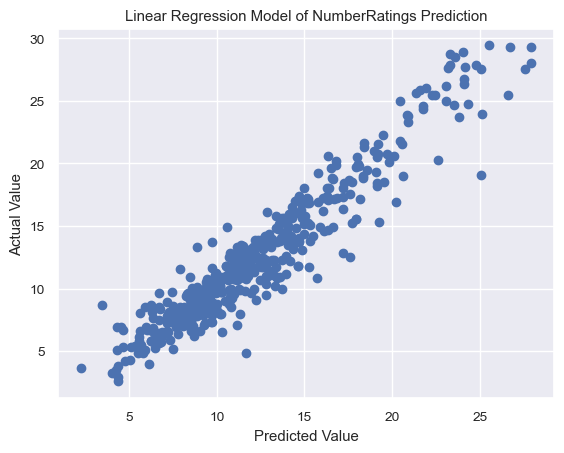

In [46]:
# plotting the Y-prediction vs Y-testing(actual value)

plt.scatter(Y_pred, Y_test, alpha=1)
plt.title('Linear Regression Model of NumberRatings Prediction')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

In [47]:
# the coefficient list

coef = df_corr_model.coef_.transpose()
pd.DataFrame(zip(X_train.columns, coef), columns=['feature','coefficient'])

,feature,coefficient
0,cbrt_Enrollment,5.895033
1,cbrt_Review,3.577601
2,cbrt_Student,-4.106594
3,InstRating,-0.219805
4,AvgRating,0.098498
5,Fee,-0.008817
6,Lectures,0.027448


- The best results were obtained using **Correlation** for feature selection, **None** Feature transformation and just the Robust scaler, since it produced the highest R² (0.8995) and the lowest RMSE (1.7655).
- Applying the Log1p transformation reduced the model performance for both feature selection methods experiments.
- From the scatter plot, we can see that the model has good predictions.
- There are no relevant outliers.
- About the coefficients, it is possible to determine which features have a positive or negative influence on the final model.

# Task 7 - Out of Sample Prediction
- Create a synthetic dataset containing at least two rows of data points that has the same columns set as the one that gives the best linear regression. You can look at the df.describe() and choose one of the rows, e.g., mean, 5% percentile, 75% percentile, etc. 

In [48]:
# Getting the summary statistics of the dataset to check the criteria for creating the synthetic dataset

df_corr.describe()

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures
count,1846.000000,1846.000000,1846.000000,1846.000000,1846.000000,1846.000000,1846.000000
mean,22.246635,26.022164,45.524747,4.427465,4.419881,21.745431,105.156555
std,9.175121,16.353787,26.044138,0.188127,0.235634,19.327291,98.952212
min,3.301927,3.141381,3.802952,3.800000,2.700000,9.301800,5.000000
25%,15.508840,13.744071,25.216648,4.300000,4.300000,16.990000,44.000000
50%,20.817385,21.984148,39.493403,4.500000,4.500000,17.990000,74.000000
75%,27.127200,33.840079,60.447862,4.600000,4.600000,21.990000,125.000000
max,56.991894,86.756354,129.445070,4.800000,4.900000,199.990000,699.000000


# Experiment with 2 rows for prediction

In [49]:
# Selecting 2 values datapoints with same columns set, extractin just mean and 75% values

stats = df[df_corr.columns].describe()

synthetic_data = pd.DataFrame([
    stats.loc["mean"],
    stats.loc["75%"]
])

synthetic_data.head()

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures
mean,22.852516,26.566290,46.203082,4.430589,4.423686,21.758858,105.238449
75%,27.463643,34.811229,61.453310,4.600000,4.600000,21.990000,125.000000


In [50]:
# Robust scaler implementation to the synthetic data set

rs = RobustScaler()
synthetic_data_scaled_features = rs.fit_transform(synthetic_data)

# Creating new data frame with the features scaled

synthetic_data_scaled = pd.DataFrame(synthetic_data_scaled_features, columns=synthetic_data.columns)
synthetic_data_scaled.head()

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures
0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [51]:
# Prediction
Y_pred = df_corr_model.predict(synthetic_data_scaled)

synthetic_data["Prediction"] = Y_pred

synthetic_data

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures,Prediction
mean,22.852516,26.566290,46.203082,4.430589,4.423686,21.758858,105.238449,6.094779
75%,27.463643,34.811229,61.453310,4.600000,4.600000,21.990000,125.000000,16.621512


# Experiment with 3 rows for prediction

In [52]:
# Selecting values datapoints with same columns set, extractin just mean, 75% and max values

stats = df[df_corr.columns].describe()

synthetic_data = pd.DataFrame([
    stats.loc["mean"],
    stats.loc["75%"],
    stats.loc["max"]
])

synthetic_data.head()

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures
mean,22.852516,26.566290,46.203082,4.430589,4.423686,21.758858,105.238449
75%,27.463643,34.811229,61.453310,4.600000,4.600000,21.990000,125.000000
max,59.825512,86.756354,129.445070,4.800000,4.900000,199.990000,699.000000


In [53]:
# Robust scaler implementation to the synthetic data set

rs = RobustScaler()
synthetic_data_scaled_features = rs.fit_transform(synthetic_data)

# Creating new data frame with the features scaled

synthetic_data_scaled = pd.DataFrame(synthetic_data_scaled_features, columns=synthetic_data.columns)
synthetic_data_scaled.head()

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures
0,-0.249432,-0.273963,-0.366407,-0.917194,-0.740328,-0.002594,-0.066564
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1.750568,1.726037,1.633593,1.082806,1.259672,1.997406,1.933436


In [54]:
# Prediction
Y_pred = df_corr_model.predict(synthetic_data_scaled)

synthetic_data["Prediction"] = Y_pred

synthetic_data

,cbrt_Enrollment,cbrt_Review,cbrt_Student,InstRating,AvgRating,Fee,Lectures,Prediction
mean,22.852516,26.566290,46.203082,4.430589,4.423686,21.758858,105.238449,10.539166
75%,27.463643,34.811229,61.453310,4.600000,4.600000,21.990000,125.000000,11.358146
max,59.825512,86.756354,129.445070,4.800000,4.900000,199.990000,699.000000,21.065899


In [55]:
# Summary statisctic for the target dataframe and focusing in the mean, 75% and max values, that i consider as the actual values

target.describe()

count    1846.000000
mean       12.187884
std         5.107729
min         2.571282
25%         8.510941
50%        11.126636
75%        14.797652
max        29.966258
Name: cbrt_NumberRatings, dtype: float64

- I noticed different prediction errors when using just 2 rows (mean and 75%) compared to using 3 rows (mean, 75%, and max).
- The predictions in the second experiment (3 rows) were more accurate, especially for the row corresponding to the mean.
- In the 2 rows experiment, the prediction using the datapoints for mean was 6.0948 and for the 75% row was 16.6215.
- In the 3 rows experiment, the prediction using the datapoints for the mean was 10.5392, for the 75% row 11.3581, and for the max row 21.0659.
- Looking at the target statistics, the actual values are 12.1879 for the mean, 14.7977 for the 75% row, and 29.9663 for the max row.